# **Trial Activation Analysis: Product Analytics and Recommendations**
## **Splendor Analytics Data Challenge**

**Author:** Ehijele David  
**Notebook:** 03 Product Analytics and Recommendations  
**Challenge:** Splendor Analytics Data Challenge  
**Date:** 23/03/2026

---

The notebook converts all technical results from data cleaning and conversion analysis work conducted in Notebook 1 into understandable operational recommendations for the Splendor product team. The notebook functions as a communication tool because it does not serve as an analytical notebook. The entire content of this document, which includes charts and metrics and recommendations, serves to provide an answer to the business question about which changes the product team should implement to enhance trial activation and conversion rates.

## **Section 1 Environment Setup**

Libraries and data loaded. The same cleaning and preparation logic
from Notebook 1 is applied here to ensure all analysis and
visualisations are built on the same clean, consistent dataset.

In [1]:
# ── Section 1: Environment Setup ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Colour palette — consistent throughout notebook
NAVY       = '#1E3A5F'
STEEL      = '#2E86AB'
LIGHT_BLUE = '#EBF4FA'
RED        = '#E74C3C'
GREEN      = '#1B7A4A'
AMBER      = '#F39C12'
MUTED      = '#6B7280'
WHITE      = '#FFFFFF'

# ============================================================
# CONFIGURATION — change only this path if data moves
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DATA_PATH = '/content/drive/MyDrive/Advanced Data Analytics/Splendor Data Challenge/DA task.csv'

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower()

# ── Data preparation — applying same logic as Notebook 1 ─────────────────────

# 1. Parse timestamps
datetime_cols = ['timestamp', 'converted_at', 'trial_start', 'trial_end']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 2. Calculate day_of_trial
df['day_of_trial'] = (
    df['timestamp'].dt.normalize() -
    df['trial_start'].dt.normalize()
).dt.days

# 3. Filter to valid trial window
df = df[(df['day_of_trial'] >= 0) & (df['day_of_trial'] <= 30)].copy()

# 4. Assign activity buckets
BUCKET_MAPPING = {
    'Scheduling.Shift.Created':                1,
    'Scheduling.Availability.Set':             1,
    'Scheduling.Template.ApplyModal.Applied':  1,
    'Mobile.Schedule.Loaded':                  1,
    'Shift.View.Opened':                       1,
    'ShiftDetails.View.Opened':                1,
    'Scheduling.ShiftSwap.Created':            2,
    'Scheduling.ShiftSwap.Accepted':           2,
    'Scheduling.ShiftHandover.Created':        2,
    'Scheduling.ShiftHandover.Accepted':       2,
    'Scheduling.OpenShiftRequest.Created':     2,
    'Scheduling.OpenShiftRequest.Approved':    2,
    'Scheduling.Shift.AssignmentChanged':      2,
    'PunchClock.PunchedIn':                    2,
    'PunchClock.PunchedOut':                   2,
    'Break.Activate.Started':                  2,
    'Break.Activate.Finished':                 2,
    'PunchClockStartNote.Add.Completed':       2,
    'PunchClockEndNote.Add.Completed':         2,
    'PunchClock.Entry.Edited':                 2,
    'Absence.Request.Created':                 2,
    'Absence.Request.Approved':                2,
    'Absence.Request.Rejected':                2,
    'Scheduling.Shift.Approved':               3,
    'Timesheets.BulkApprove.Confirmed':        3,
    'Integration.Xero.PayrollExport.Synced':   3,
    'Revenue.Budgets.Created':                 3,
    'Communication.Message.Created':           3,
}
df['activity_bucket'] = df['activity_name'].map(BUCKET_MAPPING)

# 5. Conversion timing
def assign_timing(row):
    if not row['converted']:
        return 'not_converted'
    days = (
        row['converted_at'].normalize() -
        row['trial_end'].normalize()
    ).days
    if days <= 0:
        return 'within_trial'
    elif days <= 7:
        return 'post_trial_short'
    else:
        return 'post_trial_long'

org_timing = df.drop_duplicates('organization_id').apply(
    assign_timing, axis=1
)
org_timing.index = df.drop_duplicates(
    'organization_id'
)['organization_id']
df['conversion_timing'] = df['organization_id'].map(org_timing)

# 6. Targeted deduplication
safe_to_deduplicate = [
    'PunchClock.PunchedIn',
    'Break.Activate.Started',
    'Break.Activate.Finished',
    'Scheduling.Availability.Set',
    'PunchClock.Entry.Edited',
    'Communication.Message.Created',
    'Mobile.Schedule.Loaded',
    'ShiftDetails.View.Opened',
    'Scheduling.Shift.Approved',
    'Scheduling.Shift.Created',
    'Scheduling.Shift.AssignmentChanged',
]
duplicate_mask = (
    df.duplicated(
        subset=['organization_id', 'activity_name', 'timestamp'],
        keep='first'
    ) &
    df['activity_name'].isin(safe_to_deduplicate)
)
df = df[~duplicate_mask].reset_index(drop=True)

# ── Verify ────────────────────────────────────────────────────────────────────
print("=== DATASET READY ===")
print(f"Total events:          {len(df):,}")
print(f"Unique organisations:  {df['organization_id'].nunique():,}")
print(f"Converted:             "
      f"{df[df['converted']==True]['organization_id'].nunique():,} "
      f"(21.3%)")
print(f"Date range:            "
      f"{df['timestamp'].min().date()} → "
      f"{df['timestamp'].max().date()}")

Mounted at /content/drive
=== DATASET READY ===
Total events:          102,895
Unique organisations:  966
Converted:             206 (21.3%)
Date range:            2024-01-01 → 2024-04-28


## **Section 2 The Business Context**

---

Splendor Analytics offers organizations a free trial of its workforce management platform which lasts for 30 days. The platform provides features for shift scheduling time tracking absence management payroll approvals and team communications. The conversion rate from trialing organizations to paying customers establishes a base conversion rate of 21.3% which means that approximately 1 in 5 organizations will become paying customers.

The product team needs to understand product differences which enable the 1 in 5 customers to convert while the 4 in 5 customers remain non-converting. The team lacks specific information which prevents them from making onboarding changes. Organizations experience two problems because their staff members make mistakes in product development they work on insufficiently understood features which results in unidentified reasons for customer loss.

The commissioned analysis aims to provide a solution for the existing problem. The research begins with 170,526 behavioural events which were collected from 966 trialling organisations to establish the criteria of successful trials and the points at which organisations stop participating. The system establishes data infrastructure which enables organizations to monitor their trial progress during large-scale operations. The notebook presents research results through simple explanations which show the results and their impact on the product and the future work priorities of the team.

**A note on event counts:** The raw dataset of 170,526 events was reduced
to 102,895 events for analysis. The decrease in size was implemented with full
documentation to support its existence. Data cleaning discovered duplicate events which occurred when the same organization performed identical activities at the same time. The events duplicated because users activated several UI elements or they made network attempts or platform instrumentation recorded events multiple times for each user action. The duplicates were removed because they represented pipeline artifacts which did not reflect actual user activities. The main purpose of pipeline artifacts was to produce higher activity rates but they would interfere with any analysis which depended on activity patterns. The system maintained complete access to all 966 organizations together with their 21.3% conversion rate because only redundant event rows were deleted.

## **Section 3 Who Is Trialling the Platform**

This section provides a descriptive overview of the trial population.
The product team requires user identification through data because
they need to understand which organizations participated in trials and
which organizations began testing during each month of the study.

=== TRIAL POPULATION OVERVIEW ===
Total organisations:    966
Converted:              206  (21.3%)
Not converted:          760  (78.7%)

=== COHORT BREAKDOWN ===
cohort_month  total_orgs  converted  conversion_rate  not_converted
     2024-01         305         70             23.0            235
     2024-02         347         79             22.8            268
     2024-03         314         57             18.2            257

=== CONVERSION TIMING ===
conversion_timing  count
    not_converted    760
  post_trial_long     38
 post_trial_short     63
     within_trial    105


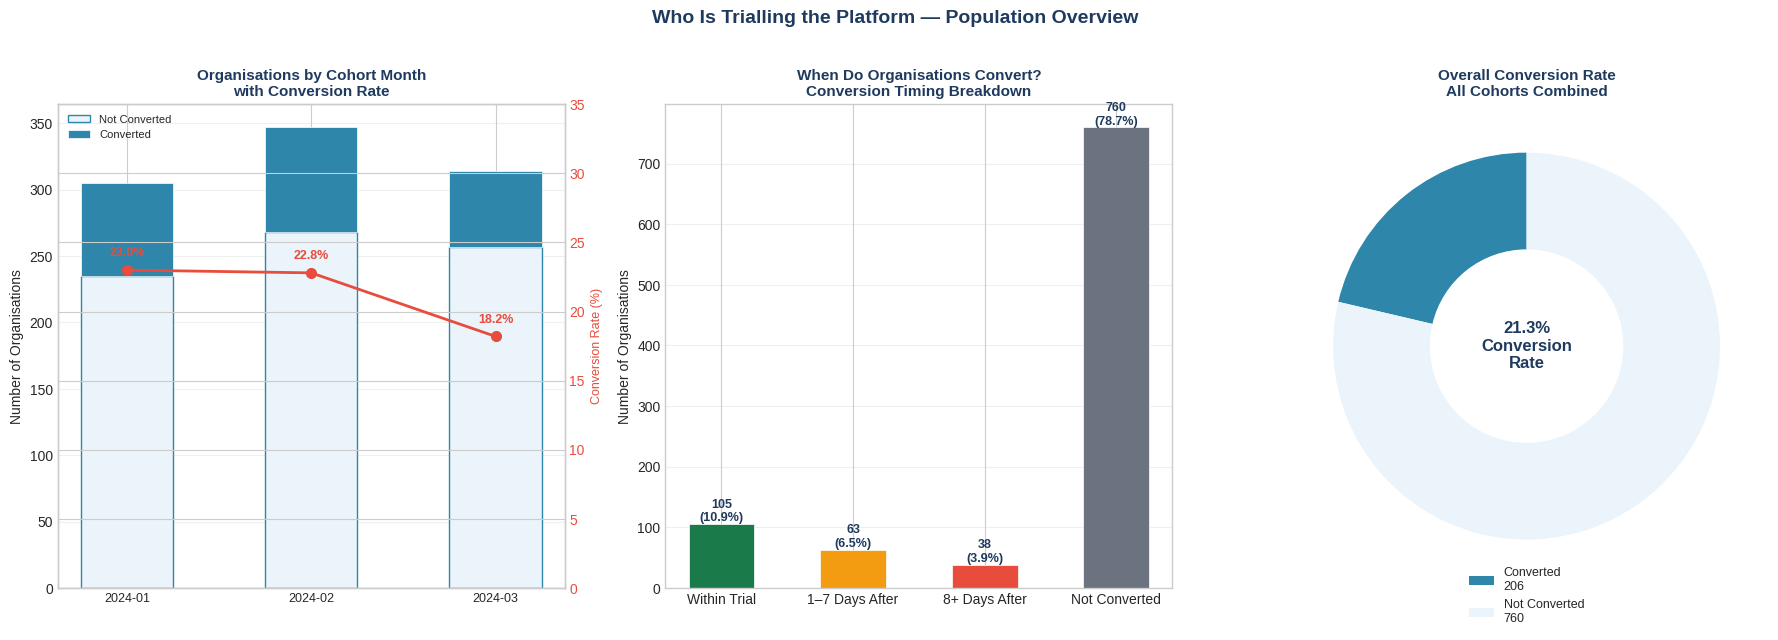

Charts saved.


In [3]:
# ── Section 3: Who Is Trialling the Platform ──────────────────────────────────

# ── Org-level summary ─────────────────────────────────────────────────────────
org_summary = df.groupby('organization_id').agg(
    converted          = ('converted', 'first'),
    conversion_timing  = ('conversion_timing', 'first'),
    trial_start        = ('trial_start', 'first'),
    total_events       = ('activity_name', 'count'),
    distinct_activities= ('activity_name', 'nunique'),
    last_day_active    = ('day_of_trial', 'max')
).reset_index()

org_summary['cohort_month'] = pd.to_datetime(
    org_summary['trial_start']
).dt.to_period('M').astype(str)

# ── Cohort breakdown ──────────────────────────────────────────────────────────
cohort = org_summary.groupby('cohort_month').agg(
    total_orgs  = ('organization_id', 'count'),
    converted   = ('converted', 'sum')
).reset_index()
cohort['conversion_rate'] = (cohort['converted'] / cohort['total_orgs'] * 100).round(1)
cohort['not_converted']   = cohort['total_orgs'] - cohort['converted']

# ── Conversion timing breakdown ───────────────────────────────────────────────
timing = org_summary.groupby('conversion_timing').agg(
    count = ('organization_id', 'count')
).reset_index()

total_orgs = len(org_summary)
converted  = org_summary['converted'].sum()

print("=== TRIAL POPULATION OVERVIEW ===")
print(f"Total organisations:    {total_orgs:,}")
print(f"Converted:              {converted:,}  ({converted/total_orgs*100:.1f}%)")
print(f"Not converted:          {total_orgs - converted:,}  ({(total_orgs-converted)/total_orgs*100:.1f}%)")
print(f"\n=== COHORT BREAKDOWN ===")
print(cohort.to_string(index=False))
print(f"\n=== CONVERSION TIMING ===")
print(timing.to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(WHITE)
fig.suptitle(
    'Who Is Trialling the Platform — Population Overview',
    fontsize=14, fontweight='bold', color=NAVY, y=1.02
)

# Chart 1 — Orgs per cohort with conversion rate overlay
x = np.arange(len(cohort))
axes[0].set_facecolor(WHITE)
axes[0].bar(x, cohort['not_converted'], width=0.5,
            color=LIGHT_BLUE, edgecolor=STEEL,
            linewidth=1, label='Not Converted')
axes[0].bar(x, cohort['converted'], width=0.5,
            bottom=cohort['not_converted'],
            color=STEEL, edgecolor=WHITE,
            linewidth=0.5, label='Converted')

ax2 = axes[0].twinx()
ax2.plot(x, cohort['conversion_rate'],
         color=RED, linewidth=2,
         marker='o', markersize=7,
         label='Conversion Rate %')
ax2.set_ylabel('Conversion Rate (%)', fontsize=9, color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax2.set_ylim(0, 35)

for i, row in cohort.iterrows():
    ax2.annotate(
        f"{row['conversion_rate']}%",
        xy=(i, row['conversion_rate']),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9,
        fontweight='bold', color=RED
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(cohort['cohort_month'], fontsize=9)
axes[0].set_ylabel('Number of Organisations', fontsize=10)
axes[0].set_title('Organisations by Cohort Month\nwith Conversion Rate',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2 — Conversion timing breakdown
timing_order  = ['within_trial','post_trial_short','post_trial_long','not_converted']
timing_labels = ['Within Trial','1–7 Days After','8+ Days After','Not Converted']
timing_colors = [GREEN, AMBER, RED, MUTED]
timing_counts = [
    timing[timing['conversion_timing'] == t]['count'].values[0]
    if t in timing['conversion_timing'].values else 0
    for t in timing_order
]

axes[1].set_facecolor(WHITE)
bars = axes[1].bar(
    timing_labels, timing_counts,
    color=timing_colors, edgecolor=WHITE,
    linewidth=0.5, width=0.5
)
for bar, count in zip(bars, timing_counts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{count:,}\n({count/total_orgs*100:.1f}%)',
        ha='center', fontsize=9,
        fontweight='bold', color=NAVY
    )
axes[1].set_ylabel('Number of Organisations', fontsize=10)
axes[1].set_title('When Do Organisations Convert?\nConversion Timing Breakdown',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].grid(True, alpha=0.3, axis='y')

# Chart 3 — Overall conversion summary donut
donut_sizes  = [converted, total_orgs - converted]
donut_colors = [STEEL, LIGHT_BLUE]
donut_labels = [f'Converted\n{converted:,}', f'Not Converted\n{total_orgs-converted:,}']

wedges, texts = axes[2].pie(
    donut_sizes, colors=donut_colors,
    startangle=90, wedgeprops=dict(width=0.5)
)
axes[2].text(0, 0, f'21.3%\nConversion\nRate',
             ha='center', va='center',
             fontsize=12, fontweight='bold', color=NAVY)
axes[2].legend(wedges, donut_labels, fontsize=9,
               loc='lower center', bbox_to_anchor=(0.5, -0.1))
axes[2].set_title('Overall Conversion Rate\nAll Cohorts Combined',
                  fontsize=11, fontweight='bold', color=NAVY)

plt.tight_layout()
plt.savefig('section3_population.png', dpi=150,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Charts saved.")

### **What the Data Shows**

**The trial population is healthy and consistent.** The platform underwent testing by 966 organizations during three months which included the months of January and February and March 2024. The cohorts show similar sizes which range from 305 to 347 organizations per month because no single month drives the overall results at an excessive level.

**The 21.3% conversion rate is stable but fragile.** About 1 in 5 organizations across all three cohorts achieves conversion. January and February show nearly identical results with 23.0% and 22.8% as their respective conversion rates. The March conversion rate decreased to 18.2% which represents a significant difference. The data cleaning section shows that 70 organizations began their trial during the last week of March which caused their 30-day trial period to continue past the dataset cutoff point. The incomplete event history for their activities probably caused the March conversion rate to decrease instead of actual changes in their behavior or product performance.

**Most conversions do not happen during the trial.**
The 206 organisations that converted only achieved conversion through their 30-day trial period which was the only time their trial period. 63 people converted within 7 days after the trial ended while 38 people converted 8 or more days after. The trial establishes a crucial point because it directs customers to choose their conversion path which they will follow after the trial ends. The platform functions correctly during the trial period yet the payment process requires time because organizations use their internal procedures to approve payments. The conversion rate functions as a delayed indicator because organizations which show up as non-converters in this dataset will eventually complete their conversion after they receive additional time.

**The core problem remains unchanged.**
78.7% of trialling organisations do not convert.760 organisations per cohort cycle disappeared after they tested the platform. The next sections examine what they did — and did not do — during their trial.

## **Section 4 How Organisations Actually Use the Platform**

Most product teams assume trialists explore the platform progressively
by logging in multiple times to discover features which they will learn
to use before making their decision. The data tells a different story.
This section shows what a typical trial actually looks like and it
explains why there is a larger gap between signing up and experiencing
the platform than people expect.

=== TYPICAL TRIAL ENGAGEMENT ===

All organisations:
  Median total events:        8
  Median distinct activities: 2
  Median days active:         1
  Median last day active:     0

=== ONE-TOUCH ORGANISATIONS ===
Active Day 0 only:            562  (58.2%)
One-touch conversion rate:    21.5%
Multi-touch conversion rate:  21.0%
Baseline conversion rate:     21.3%

=== ENGAGEMENT DEPTH BREAKDOWN ===
  Day 0 only       562 orgs  ( 58.2%)  Conv rate: 21.5%
  Days 1–7         139 orgs  ( 14.4%)  Conv rate: 20.1%
  Days 8–14         51 orgs  (  5.3%)  Conv rate: 13.7%
  Days 15–21        29 orgs  (  3.0%)  Conv rate: 13.8%
  Days 22–30       185 orgs  ( 19.2%)  Conv rate: 24.9%


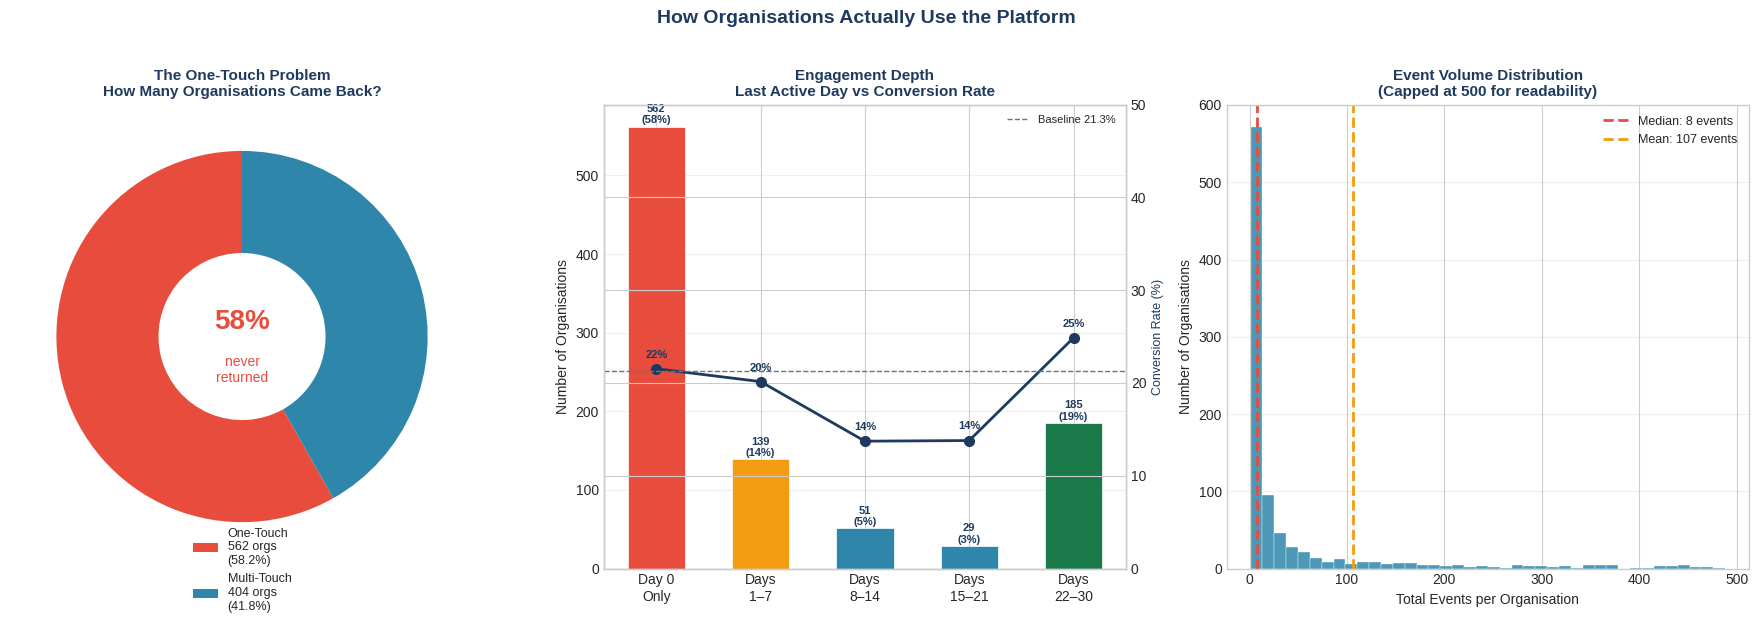

Charts saved.


In [4]:
# ── Section 4: How Organisations Actually Use the Platform ────────────────────

# ── Engagement profile per org ────────────────────────────────────────────────
org_engagement = df.groupby('organization_id').agg(
    converted           = ('converted', 'first'),
    total_events        = ('activity_name', 'count'),
    distinct_activities = ('activity_name', 'nunique'),
    days_active         = ('day_of_trial', 'nunique'),
    last_day_active     = ('day_of_trial', 'max'),
    first_day_active    = ('day_of_trial', 'min'),
).reset_index()

# ── One-touch classification ──────────────────────────────────────────────────
org_engagement['one_touch'] = (org_engagement['last_day_active'] == 0).astype(int)

one_touch      = org_engagement[org_engagement['one_touch'] == 1]
multi_touch    = org_engagement[org_engagement['one_touch'] == 0]
total_orgs     = len(org_engagement)

one_touch_cr   = one_touch['converted'].mean() * 100
multi_touch_cr = multi_touch['converted'].mean() * 100

print("=== TYPICAL TRIAL ENGAGEMENT ===")
print(f"\nAll organisations:")
print(f"  Median total events:        {org_engagement['total_events'].median():.0f}")
print(f"  Median distinct activities: {org_engagement['distinct_activities'].median():.0f}")
print(f"  Median days active:         {org_engagement['days_active'].median():.0f}")
print(f"  Median last day active:     {org_engagement['last_day_active'].median():.0f}")

print(f"\n=== ONE-TOUCH ORGANISATIONS ===")
print(f"Active Day 0 only:            {len(one_touch):,}  ({len(one_touch)/total_orgs*100:.1f}%)")
print(f"One-touch conversion rate:    {one_touch_cr:.1f}%")
print(f"Multi-touch conversion rate:  {multi_touch_cr:.1f}%")
print(f"Baseline conversion rate:     21.3%")

print(f"\n=== ENGAGEMENT DEPTH BREAKDOWN ===")
buckets = [
    ('Day 0 only',    org_engagement['last_day_active'] == 0),
    ('Days 1–7',     (org_engagement['last_day_active'] >= 1)  & (org_engagement['last_day_active'] <= 7)),
    ('Days 8–14',    (org_engagement['last_day_active'] >= 8)  & (org_engagement['last_day_active'] <= 14)),
    ('Days 15–21',   (org_engagement['last_day_active'] >= 15) & (org_engagement['last_day_active'] <= 21)),
    ('Days 22–30',   (org_engagement['last_day_active'] >= 22)),
]
for label, mask in buckets:
    subset = org_engagement[mask]
    cr     = subset['converted'].mean() * 100 if len(subset) > 0 else 0
    print(f"  {label:<15} {len(subset):>4} orgs  ({len(subset)/total_orgs*100:>5.1f}%)  Conv rate: {cr:.1f}%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(WHITE)
fig.suptitle(
    'How Organisations Actually Use the Platform',
    fontsize=14, fontweight='bold', color=NAVY, y=1.02
)

# Chart 1 — One-touch vs multi-touch
labels        = [f'One-Touch\n{len(one_touch):,} orgs\n(58.2%)',
                 f'Multi-Touch\n{len(multi_touch):,} orgs\n(41.8%)']
sizes         = [len(one_touch), len(multi_touch)]
chart1_colors = [RED, STEEL]

axes[0].set_facecolor(WHITE)
wedges, texts = axes[0].pie(
    sizes, colors=chart1_colors,
    startangle=90, wedgeprops=dict(width=0.55)
)
axes[0].text(0, 0.08, f'{len(one_touch)/total_orgs*100:.0f}%',
             ha='center', va='center',
             fontsize=20, fontweight='bold', color=RED)
axes[0].text(0, -0.18, 'never\nreturned',
             ha='center', va='center',
             fontsize=10, color=RED)
axes[0].legend(wedges, labels, fontsize=9,
               loc='lower center', bbox_to_anchor=(0.5, -0.12))
axes[0].set_title('The One-Touch Problem\nHow Many Organisations Came Back?',
                  fontsize=11, fontweight='bold', color=NAVY)

# Chart 2 — Engagement depth distribution with conversion rate overlay
depth_labels  = ['Day 0\nOnly', 'Days\n1–7', 'Days\n8–14', 'Days\n15–21', 'Days\n22–30']
depth_counts  = [org_engagement[mask].shape[0] for _, mask in buckets]
depth_cr      = [
    org_engagement[mask]['converted'].mean() * 100
    for _, mask in buckets
]
depth_colors  = [RED, AMBER, STEEL, STEEL, GREEN]

axes[1].set_facecolor(WHITE)
bars = axes[1].bar(
    depth_labels, depth_counts,
    color=depth_colors, edgecolor=WHITE,
    linewidth=0.5, width=0.55
)
for bar, count in zip(bars, depth_counts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 4,
        f'{count:,}\n({count/total_orgs*100:.0f}%)',
        ha='center', fontsize=8,
        fontweight='bold', color=NAVY
    )

ax2 = axes[1].twinx()
ax2.plot(depth_labels, depth_cr,
         color=NAVY, linewidth=2,
         marker='o', markersize=7)
ax2.axhline(21.3, color=MUTED, linestyle='--',
            linewidth=1, label='Baseline 21.3%')
for i, cr in enumerate(depth_cr):
    ax2.annotate(
        f'{cr:.0f}%',
        xy=(i, cr), xytext=(0, 8),
        textcoords='offset points',
        ha='center', fontsize=8,
        fontweight='bold', color=NAVY
    )
ax2.set_ylabel('Conversion Rate (%)', fontsize=9, color=NAVY)
ax2.set_ylim(0, 50)
ax2.legend(fontsize=8, loc='upper right')

axes[1].set_ylabel('Number of Organisations', fontsize=10)
axes[1].set_title('Engagement Depth\nLast Active Day vs Conversion Rate',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].grid(True, alpha=0.3, axis='y')

# Chart 3 — Event volume distribution (log scale to handle skew)
axes[2].set_facecolor(WHITE)
axes[2].hist(
    org_engagement[org_engagement['total_events'] <= 500]['total_events'],
    bins=40, color=STEEL, edgecolor=WHITE,
    linewidth=0.3, alpha=0.85
)
axes[2].axvline(
    org_engagement['total_events'].median(),
    color=RED, linewidth=2, linestyle='--',
    label=f"Median: {org_engagement['total_events'].median():.0f} events"
)
axes[2].axvline(
    org_engagement['total_events'].mean(),
    color=AMBER, linewidth=2, linestyle='--',
    label=f"Mean: {org_engagement['total_events'].mean():.0f} events"
)
axes[2].set_xlabel('Total Events per Organisation', fontsize=10)
axes[2].set_ylabel('Number of Organisations', fontsize=10)
axes[2].set_title('Event Volume Distribution\n(Capped at 500 for readability)',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('section4_engagement.png', dpi=150,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Charts saved.")

### **What the Data Shows**

The typical trial is a single session which assesses all evidence. The median organisation generated just 8 events across 2 distinct activities, was active for 1 day, and was last seen on Day 0, their first day. The operation lacks any elements that could define it as a trial. The organisation made its decision after the single visit and departed.

**58% of trialling organisations never came back.**
A total of 562 organisations out of 966 remained active only during the first day. The visitors signed up for the service but they did not come back after exploring the platform. The striking finding is that their conversion rate of 21.5%, is statistically identical to the 21.3% overall baseline. An organisation that used the platform once converts at exactly the same rate as one that used it for two weeks. The majority of trialists make their conversion decision before they use the platform because they spend time with it. The decision occurs through sales conversations and pricing evaluations and internal procurement processes which all take place outside the event log.

**Conversion results from direct correlation to longer engagement period.**
The engagement depth chart displays its non-linear pattern of user interaction. The
organisations display conversion rates which actually fall below baseline during their
active periods from Days 1 to 7 and Days 8 to 21. The organisations that maintained
their operations from Days 22 to 30 were the only groups which achieved conversion
rates above baseline with their 24.9% rate. The mid-trial engagement pattern without
follow-through indicates that users now face evaluation uncertainty rather than actual
adoption intentions. The organisations which maintain their engagement throughout
the entire trial period represent the highest conversion potential although they make
up only 19.2% of all trialists.

**The distribution of event volume shows extreme skewness.**
The mean of 107 events versus a median of 8 tells the same story
visually about the platform usage pattern which shows that
only a few high-activity organisations drive up the average
while most users show almost no platform activity. The dataset requires
all metrics to use standard event volume because any other method
would produce incorrect results.

**The product team needs to address this specific issue** because organizations
struggle to complete their first actual trial experience with their
product testing process. The study requires organisations to use
the entire intervention period in order to test all features. The
main goal of this project requires organisations to reach
their first operational day after Day 0.

## **Section 5 Where the Trial Breaks Down & The Activation Framework**

Most organisations fail to establish any meaningful interaction with the platform which has been demonstrated in the previous section. This section goes one level deeper — for the organisations that did engage, where exactly did they stop? The activation funnel maps the four goals that define a complete trial experience, shows where the largest drop-off occurs, and introduces the framework the product team can use to track trial health going forward.

=== GOAL COMPLETION RATES ===
  Goal 1:  848 orgs (87.8%)  Conv rate: 21.8%
  Goal 2:  211 orgs (21.8%)  Conv rate: 22.7%
  Goal 3:  214 orgs (22.2%)  Conv rate: 22.0%
  Goal 4:  253 orgs (26.2%)  Conv rate: 23.3%

=== ACTIVATION SUMMARY ===
Fully activated (all 4 goals): 104  (10.8%)
Activated conversion rate:     21.2%
Not activated conversion rate: 21.3%
Overall baseline:              21.3%


/tmp/ipykernel_1845/369461462.py:164: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/369461462.py:165: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('section5_activation.png', dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


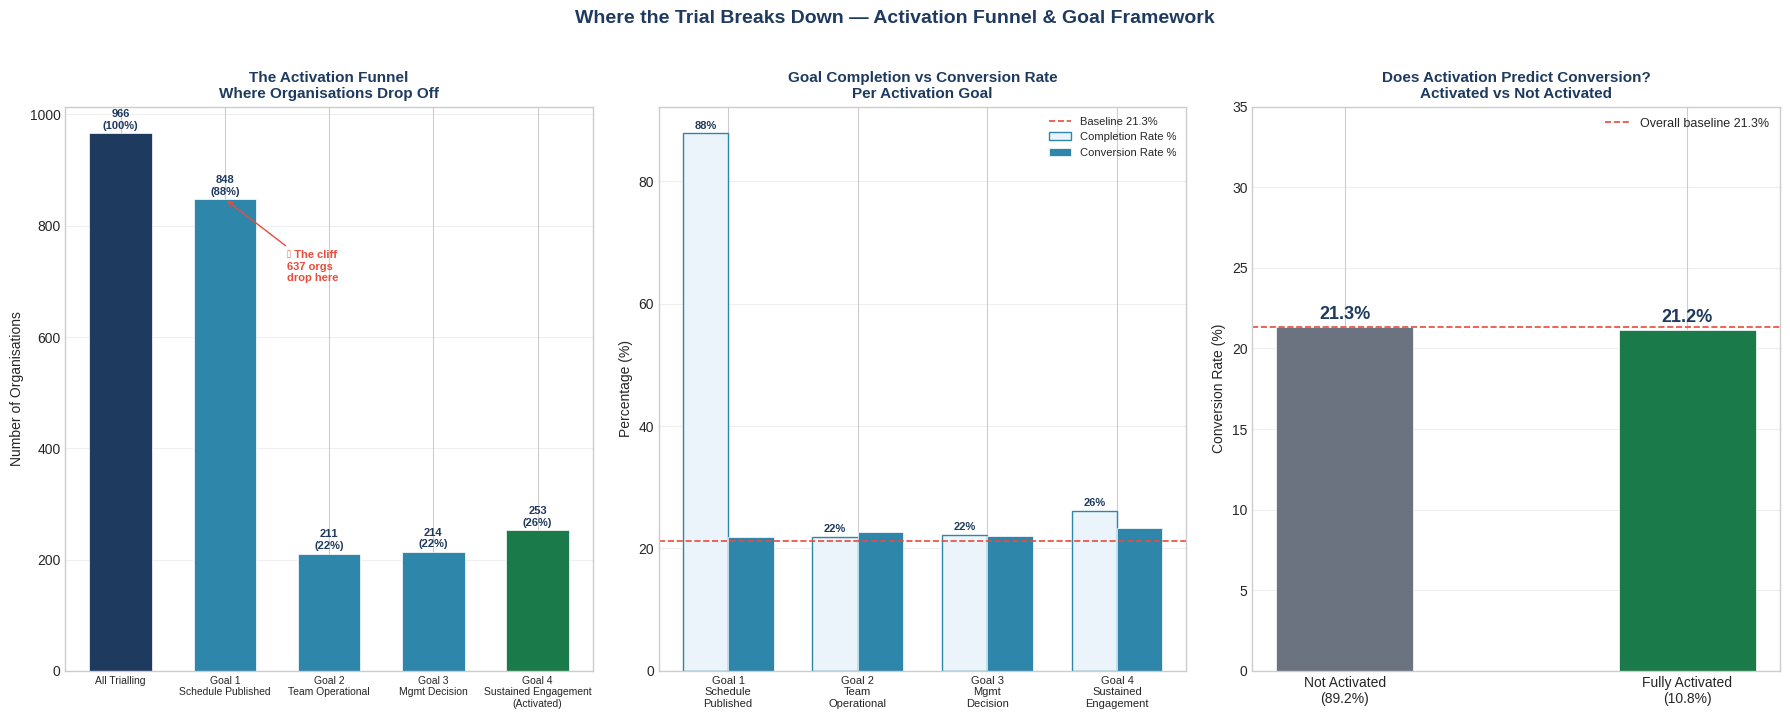

Charts saved.


In [5]:
# ── Section 5: Activation Funnel & Trial Goal Framework ───────────────────────

# ── Goal completion ───────────────────────────────────────────────────────────
org_goals = df.groupby('organization_id').agg(
    converted   = ('converted', 'first'),
    trial_start = ('trial_start', 'first'),
).reset_index()

# Goal 1 — Schedule Published
goal1_orgs = set(df[df['activity_name'] == 'Scheduling.Shift.Created']['organization_id'])
org_goals['goal1'] = org_goals['organization_id'].isin(goal1_orgs).astype(int)

# Goal 2 — Team Operational
goal2_orgs = set(df[df['activity_name'] == 'PunchClock.PunchedIn']['organization_id'])
org_goals['goal2'] = org_goals['organization_id'].isin(goal2_orgs).astype(int)

# Goal 3 — Management Decision Recorded
goal3_acts = ['Scheduling.Shift.Approved','Absence.Request.Approved','Absence.Request.Rejected']
goal3_orgs = set(df[df['activity_name'].isin(goal3_acts)]['organization_id'])
org_goals['goal3'] = org_goals['organization_id'].isin(goal3_orgs).astype(int)

# Goal 4 — Sustained Engagement
days_active = df.groupby('organization_id')['day_of_trial'].nunique()
goal4_orgs  = set(days_active[days_active >= 3].index)
org_goals['goal4'] = org_goals['organization_id'].isin(goal4_orgs).astype(int)

# Full activation
goal_cols            = ['goal1','goal2','goal3','goal4']
org_goals['activated'] = (org_goals[goal_cols].sum(axis=1) == 4).astype(int)

total_orgs  = len(org_goals)
activated   = org_goals[org_goals['activated'] == 1]
not_activ   = org_goals[org_goals['activated'] == 0]

# ── Funnel numbers ────────────────────────────────────────────────────────────
funnel = {
    'All Trialling'     : total_orgs,
    'Goal 1\nSchedule Published'   : org_goals['goal1'].sum(),
    'Goal 2\nTeam Operational'     : org_goals['goal2'].sum(),
    'Goal 3\nMgmt Decision'        : org_goals['goal3'].sum(),
    'Goal 4\nSustained Engagement\n(Activated)' : org_goals['goal4'].sum(),
}

print("=== GOAL COMPLETION RATES ===")
for col, label in zip(goal_cols, ['Goal 1','Goal 2','Goal 3','Goal 4']):
    n    = org_goals[col].sum()
    pct  = n / total_orgs * 100
    cr   = org_goals[org_goals[col]==1]['converted'].mean() * 100
    print(f"  {label}: {n:>4} orgs ({pct:.1f}%)  Conv rate: {cr:.1f}%")

print(f"\n=== ACTIVATION SUMMARY ===")
print(f"Fully activated (all 4 goals): {len(activated):,}  ({len(activated)/total_orgs*100:.1f}%)")
print(f"Activated conversion rate:     {activated['converted'].mean()*100:.1f}%")
print(f"Not activated conversion rate: {not_activ['converted'].mean()*100:.1f}%")
print(f"Overall baseline:              21.3%")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor(WHITE)
fig.suptitle(
    'Where the Trial Breaks Down — Activation Funnel & Goal Framework',
    fontsize=14, fontweight='bold', color=NAVY, y=1.02
)

# Chart 1 — Activation funnel
funnel_labels = list(funnel.keys())
funnel_counts = list(funnel.values())
funnel_colors = [NAVY, STEEL, STEEL, STEEL, GREEN]

axes[0].set_facecolor(WHITE)
bars = axes[0].bar(
    range(len(funnel_labels)), funnel_counts,
    color=funnel_colors, edgecolor=WHITE,
    linewidth=0.5, width=0.6
)
for bar, count in zip(bars, funnel_counts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 8,
        f'{count:,}\n({count/total_orgs*100:.0f}%)',
        ha='center', fontsize=8,
        fontweight='bold', color=NAVY
    )

# Annotate the cliff
axes[0].annotate(
    '⚠ The cliff\n637 orgs\ndrop here',
    xy=(1, org_goals['goal1'].sum()),
    xytext=(1.6, 700),
    fontsize=8, color=RED,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=RED)
)

axes[0].set_xticks(range(len(funnel_labels)))
axes[0].set_xticklabels(funnel_labels, fontsize=7.5)
axes[0].set_ylabel('Number of Organisations', fontsize=10)
axes[0].set_title('The Activation Funnel\nWhere Organisations Drop Off',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2 — Goal completion vs conversion rate side by side
goal_labels   = ['Goal 1\nSchedule\nPublished',
                 'Goal 2\nTeam\nOperational',
                 'Goal 3\nMgmt\nDecision',
                 'Goal 4\nSustained\nEngagement']
completion    = [org_goals[col].mean()*100 for col in goal_cols]
conv_by_goal  = [org_goals[org_goals[col]==1]['converted'].mean()*100 for col in goal_cols]

x = np.arange(len(goal_labels))
w = 0.35

axes[1].set_facecolor(WHITE)
axes[1].bar(x - w/2, completion, w,
            color=LIGHT_BLUE, edgecolor=STEEL,
            linewidth=1, label='Completion Rate %')
axes[1].bar(x + w/2, conv_by_goal, w,
            color=STEEL, edgecolor=WHITE,
            linewidth=0.5, label='Conversion Rate %')
axes[1].axhline(21.3, color=RED, linestyle='--',
                linewidth=1.2, label='Baseline 21.3%')

for i, (comp, conv) in enumerate(zip(completion, conv_by_goal)):
    axes[1].text(i - w/2, comp + 0.8, f'{comp:.0f}%',
                 ha='center', fontsize=8, color=NAVY, fontweight='bold')
    axes[1].text(i + w/2, conv + 0.8, f'{conv:.0f}%',
                 ha='center', fontsize=8, color=WHITE, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(goal_labels, fontsize=8)
axes[1].set_ylabel('Percentage (%)', fontsize=10)
axes[1].set_title('Goal Completion vs Conversion Rate\nPer Activation Goal',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

# Chart 3 — Activated vs not activated conversion rate
categories = ['Not Activated\n(89.2%)', 'Fully Activated\n(10.8%)']
conv_vals  = [not_activ['converted'].mean()*100,
              activated['converted'].mean()*100]
bar_colors = [MUTED, GREEN]

axes[2].set_facecolor(WHITE)
bars = axes[2].bar(categories, conv_vals,
                   color=bar_colors, edgecolor=WHITE,
                   linewidth=0.5, width=0.4)
axes[2].axhline(21.3, color=RED, linestyle='--',
                linewidth=1.2, label='Overall baseline 21.3%')
for bar, rate in zip(bars, conv_vals):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center', fontsize=13,
        fontweight='bold', color=NAVY
    )
axes[2].set_ylabel('Conversion Rate (%)', fontsize=10)
axes[2].set_title('Does Activation Predict Conversion?\nActivated vs Not Activated',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[2].set_ylim(0, 35)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('section5_activation.png', dpi=150,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Charts saved.")

### **What the Data Shows**

**The trial breaks down at one point between Goal 1 and Goal 2.**

A total of 848 organisations which represents 87.8 percent of organisations published a schedule. Only 211 (21.8%) ever
had a team member clock in. The drop in organisations reached 637 organisations which represents 66 percent of all trialists who had planned to use the platform but never executed work on it. The platform loses the majority of its trialists at the exact point where it transitions from a planning tool to an operational
one. Organisations that do cross this threshold tend to complete the
rest of the journey. The entry point into the operational loop functions as the bottleneck which restricts movement through the system.

The study showed that activation would not lead to conversion which emerged as a significant result. The 104 organizations reached conversion through all four goals which constituted 10.8 percent of their total population. Their conversion rate stands at 21.2 percent which matches the 21.3 percent baseline. The activation framework does not function as a tool for predicting conversions. The system functions as a **product health diagnostic** which measures how deeply organizations experienced the platform's core value without considering their payment status.

**The four goals define what a complete trial looks like:**
- **Goal 1: Schedule Published:** Entry point. 87.8% completion.
- **Goal 2: Team Operational:** The critical gate. 21.8% completion.
- **Goal 3: Management Decision Recorded:** 22.2% completion.
- **Goal 4: Sustained Engagement:** 26.2% completion.

Conversion lifts across all four goals are modest (+0.5pp to +2.0pp).
These goals are **evidence-informed hypotheses about product value**,
not guaranteed conversion levers.

## **Section 6 Product Metrics Dashboard**

This section translates the analysis into a set of forward-looking metrics
the product team can track continuously. The team uses the following metrics
to measure trial health through three different indicators which include cohort-level conversion trends
module adoption and time-to-operational. The team will use these metrics
as the monitoring baseline for all upcoming onboarding interventions which they will conduct.

=== METRIC 1 & 2: COHORT CONVERSION AND ACTIVATION ===
cohort_month  total  converted  conversion_rate  activated  activation_rate
     2024-01    305         70             23.0         39             12.8
     2024-02    347         79             22.8         32              9.2
     2024-03    314         57             18.2         33             10.5

=== METRIC 3: TIME TO FIRST BUCKET 2 ACTION ===
           count  mean  std  min  25%  50%  75%   max
converted                                            
False      330.0   2.8  5.9  0.0  0.0  0.0  2.0  28.0
True        97.0   2.6  5.8  0.0  0.0  0.0  1.0  29.0

=== METRIC 4: MODULE ADOPTION RATES ===
            module  adoption_pct  conversion_rate
Absence Management           4.1             20.0
 Shift Flexibility           5.3             27.5
        Attendance          21.8             22.7
   Payroll & Comms          27.3             20.1
        Scheduling          88.2             21.9

=== METRIC 5: GOAL FUNNEL KPI ===


/tmp/ipykernel_1845/2621872974.py:185: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(


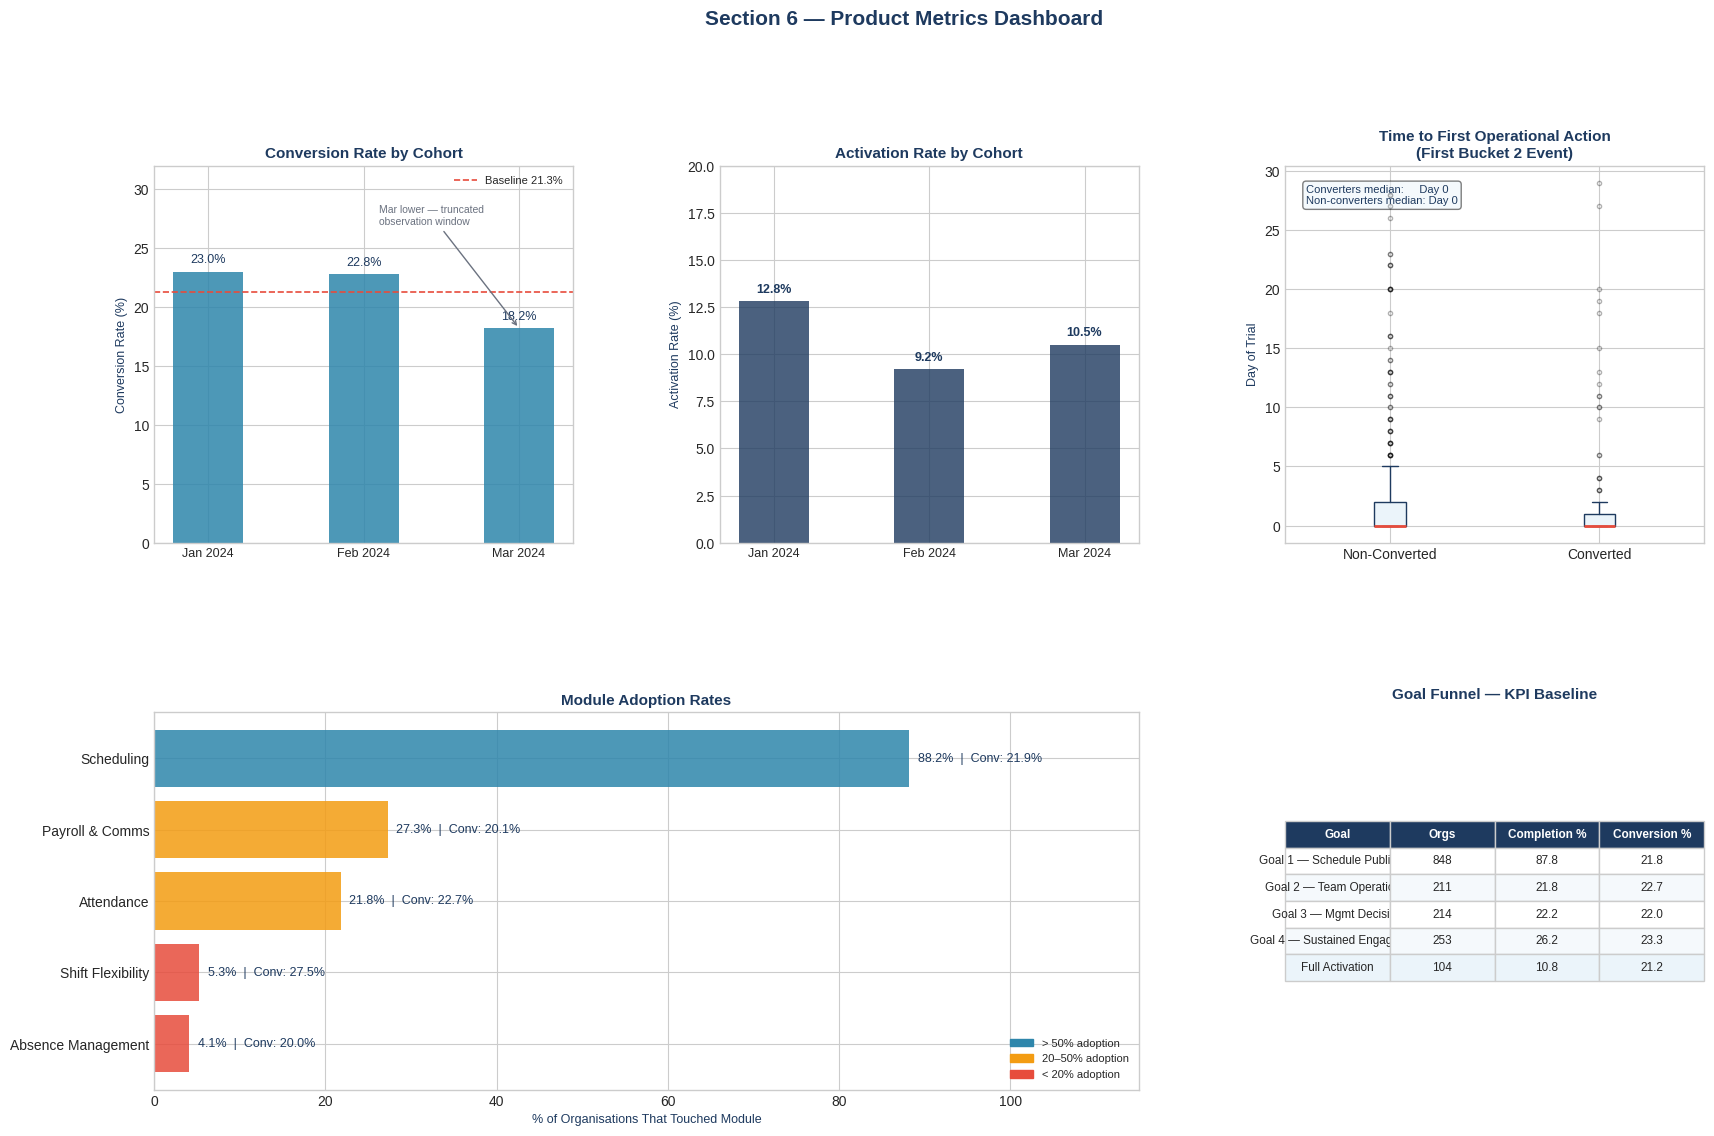

Dashboard saved.


In [7]:
# ── Section 6: Product Metrics Dashboard ─────────────────────────────────────

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

# ── Base org-level summary (builds on cleaned df from Section 1) ──────────────
org_metrics = df.groupby('organization_id').agg(
    converted         = ('converted', 'first'),
    conversion_timing = ('conversion_timing', 'first'),
    trial_start       = ('trial_start', 'first'),
    days_active       = ('day_of_trial', 'nunique'),
    last_day_active   = ('day_of_trial', 'max'),
).reset_index()

org_metrics['cohort_month'] = pd.to_datetime(
    org_metrics['trial_start']
).dt.to_period('M').astype(str)

# ── Goal flags (consistent with Section 5) ───────────────────────────────────
goal1_orgs = set(df[df['activity_name'] == 'Scheduling.Shift.Created']['organization_id'])
goal2_orgs = set(df[df['activity_name'] == 'PunchClock.PunchedIn']['organization_id'])
goal3_acts = ['Scheduling.Shift.Approved','Absence.Request.Approved','Absence.Request.Rejected']
goal3_orgs = set(df[df['activity_name'].isin(goal3_acts)]['organization_id'])
days_act   = df.groupby('organization_id')['day_of_trial'].nunique()
goal4_orgs = set(days_act[days_act >= 3].index)

org_metrics['goal1']     = org_metrics['organization_id'].isin(goal1_orgs).astype(int)
org_metrics['goal2']     = org_metrics['organization_id'].isin(goal2_orgs).astype(int)
org_metrics['goal3']     = org_metrics['organization_id'].isin(goal3_orgs).astype(int)
org_metrics['goal4']     = org_metrics['organization_id'].isin(goal4_orgs).astype(int)
org_metrics['activated'] = (org_metrics[['goal1','goal2','goal3','goal4']].sum(axis=1) == 4).astype(int)

# ── Metric 1 & 2: Conversion and Activation Rate by Cohort ───────────────────
cohort_metrics = org_metrics.groupby('cohort_month').agg(
    total      = ('organization_id', 'count'),
    converted  = ('converted', 'sum'),
    activated  = ('activated', 'sum'),
).reset_index()
cohort_metrics['conversion_rate'] = (cohort_metrics['converted'] / cohort_metrics['total'] * 100).round(1)
cohort_metrics['activation_rate'] = (cohort_metrics['activated'] / cohort_metrics['total'] * 100).round(1)

# ── Metric 3: Time to First Meaningful Action (first Bucket 2 event) ─────────
df_b2      = df[df['activity_bucket'] == 2]
first_b2   = df_b2.groupby('organization_id').agg(
    day_first_b2 = ('day_of_trial', 'min'),
    converted    = ('converted', 'first')
).reset_index()

# ── Metric 4: Module Adoption Rates ──────────────────────────────────────────
modules = {
    'Scheduling': [
        'Scheduling.Shift.Created','Scheduling.Availability.Set',
        'Scheduling.Template.ApplyModal.Applied',
        'Scheduling.Shift.AssignmentChanged'
    ],
    'Attendance': [
        'PunchClock.PunchedIn','PunchClock.PunchedOut',
        'Break.Activate.Started','Break.Activate.Finished',
        'PunchClockStartNote.Add.Completed',
        'PunchClockEndNote.Add.Completed','PunchClock.Entry.Edited'
    ],
    'Shift Flexibility': [
        'Scheduling.ShiftSwap.Created','Scheduling.ShiftSwap.Accepted',
        'Scheduling.ShiftHandover.Created','Scheduling.ShiftHandover.Accepted',
        'Scheduling.OpenShiftRequest.Created','Scheduling.OpenShiftRequest.Approved'
    ],
    'Absence Management': [
        'Absence.Request.Created','Absence.Request.Approved','Absence.Request.Rejected'
    ],
    'Payroll & Comms': [
        'Scheduling.Shift.Approved','Timesheets.BulkApprove.Confirmed',
        'Integration.Xero.PayrollExport.Synced',
        'Revenue.Budgets.Created','Communication.Message.Created'
    ],
}

total_orgs    = len(org_metrics)
module_rows   = []
for module, acts in modules.items():
    touched_ids  = set(df[df['activity_name'].isin(acts)]['organization_id'])
    adoption_pct = len(touched_ids) / total_orgs * 100
    conv_rate    = org_metrics[
        org_metrics['organization_id'].isin(touched_ids)
    ]['converted'].mean() * 100
    module_rows.append({
        'module':          module,
        'adoption_pct':    round(adoption_pct, 1),
        'conversion_rate': round(conv_rate, 1),
    })
module_df = pd.DataFrame(module_rows).sort_values('adoption_pct', ascending=True)

# ── Metric 5: Goal Funnel KPI Table ──────────────────────────────────────────
funnel_df = pd.DataFrame({
    'Goal': [
        'Goal 1 — Schedule Published',
        'Goal 2 — Team Operational',
        'Goal 3 — Mgmt Decision',
        'Goal 4 — Sustained Engagement',
        'Full Activation'
    ],
    'Orgs':         [
        org_metrics['goal1'].sum(),
        org_metrics['goal2'].sum(),
        org_metrics['goal3'].sum(),
        org_metrics['goal4'].sum(),
        org_metrics['activated'].sum()
    ],
    'Completion %': [
        round(org_metrics['goal1'].mean()*100, 1),
        round(org_metrics['goal2'].mean()*100, 1),
        round(org_metrics['goal3'].mean()*100, 1),
        round(org_metrics['goal4'].mean()*100, 1),
        round(org_metrics['activated'].mean()*100, 1)
    ],
    'Conversion %': [
        round(org_metrics[org_metrics['goal1']==1]['converted'].mean()*100, 1),
        round(org_metrics[org_metrics['goal2']==1]['converted'].mean()*100, 1),
        round(org_metrics[org_metrics['goal3']==1]['converted'].mean()*100, 1),
        round(org_metrics[org_metrics['goal4']==1]['converted'].mean()*100, 1),
        round(org_metrics[org_metrics['activated']==1]['converted'].mean()*100, 1),
    ],
})

# ── Print summary ─────────────────────────────────────────────────────────────
print("=== METRIC 1 & 2: COHORT CONVERSION AND ACTIVATION ===")
print(cohort_metrics[['cohort_month','total','converted',
                       'conversion_rate','activated','activation_rate']].to_string(index=False))

print("\n=== METRIC 3: TIME TO FIRST BUCKET 2 ACTION ===")
print(first_b2.groupby('converted')['day_first_b2'].describe().round(1).to_string())

print("\n=== METRIC 4: MODULE ADOPTION RATES ===")
print(module_df.to_string(index=False))

print("\n=== METRIC 5: GOAL FUNNEL KPI ===")
print(funnel_df.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# DASHBOARD VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(WHITE)
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: Conversion Rate by Cohort ───────────────────────────────────────
ax1   = fig.add_subplot(gs[0, 0])
x     = np.arange(len(cohort_metrics))
width = 0.35
bars1 = ax1.bar(x, cohort_metrics['conversion_rate'],
                width + 0.1, color=STEEL, alpha=0.85)
ax1.axhline(21.3, color=RED, linestyle='--', linewidth=1.2, label='Baseline 21.3%')
ax1.set_xticks(x)
ax1.set_xticklabels(['Jan 2024','Feb 2024','Mar 2024'], fontsize=9)
ax1.set_ylabel('Conversion Rate (%)', fontsize=9, color=NAVY)
ax1.set_title('Conversion Rate by Cohort', fontsize=11, fontweight='bold', color=NAVY)
ax1.set_ylim(0, 32)
ax1.legend(fontsize=8)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color=NAVY)
ax1.annotate('Mar lower — truncated\nobservation window',
             xy=(2, cohort_metrics['conversion_rate'].iloc[2]),
             xytext=(1.1, 27), fontsize=7.5, color=MUTED,
             arrowprops=dict(arrowstyle='->', color=MUTED, lw=1))

# ── Chart 2: Activation Rate by Cohort ───────────────────────────────────────
ax2   = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(x, cohort_metrics['activation_rate'],
                width + 0.1, color=NAVY, alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(['Jan 2024','Feb 2024','Mar 2024'], fontsize=9)
ax2.set_ylabel('Activation Rate (%)', fontsize=9, color=NAVY)
ax2.set_title('Activation Rate by Cohort', fontsize=11, fontweight='bold', color=NAVY)
ax2.set_ylim(0, 20)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom',
             fontsize=9, color=NAVY, fontweight='bold')

# ── Chart 3: Time to First Meaningful Action ─────────────────────────────────
ax3        = fig.add_subplot(gs[0, 2])
conv_b2    = first_b2[first_b2['converted'] == True]['day_first_b2']
nonconv_b2 = first_b2[first_b2['converted'] == False]['day_first_b2']
ax3.boxplot(
    [nonconv_b2, conv_b2],
    labels=['Non-Converted','Converted'],
    patch_artist=True,
    boxprops=dict(facecolor=LIGHT_BLUE, color=NAVY),
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color=NAVY),
    capprops=dict(color=NAVY),
    flierprops=dict(marker='o', color=MUTED, alpha=0.3, markersize=3)
)
ax3.set_ylabel('Day of Trial', fontsize=9, color=NAVY)
ax3.set_title('Time to First Operational Action\n(First Bucket 2 Event)',
              fontsize=11, fontweight='bold', color=NAVY)
ax3.text(0.05, 0.95,
         f"Converters median:     Day {int(conv_b2.median())}\n"
         f"Non-converters median: Day {int(nonconv_b2.median())}",
         transform=ax3.transAxes, fontsize=8, color=NAVY,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT_BLUE, alpha=0.5))

# ── Chart 4: Module Adoption Rates ───────────────────────────────────────────
ax4    = fig.add_subplot(gs[1, 0:2])
colors = [STEEL if a > 50 else AMBER if a > 20 else RED
          for a in module_df['adoption_pct']]
bars4  = ax4.barh(module_df['module'], module_df['adoption_pct'],
                  color=colors, alpha=0.85)
ax4.set_xlabel('% of Organisations That Touched Module', fontsize=9, color=NAVY)
ax4.set_title('Module Adoption Rates', fontsize=11, fontweight='bold', color=NAVY)
ax4.set_xlim(0, 115)
for bar, row in zip(bars4, module_df.itertuples()):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row.adoption_pct:.1f}%  |  Conv: {row.conversion_rate:.1f}%',
             va='center', fontsize=9, color=NAVY)
legend_patches = [
    mpatches.Patch(color=STEEL, label='> 50% adoption'),
    mpatches.Patch(color=AMBER, label='20–50% adoption'),
    mpatches.Patch(color=RED,   label='< 20% adoption'),
]
ax4.legend(handles=legend_patches, fontsize=8, loc='lower right')

# ── Chart 5: Goal Funnel KPI Table ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
table = ax5.table(
    cellText  = funnel_df.values,
    colLabels = funnel_df.columns,
    cellLoc   = 'center',
    loc       = 'center',
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color=WHITE, fontweight='bold')
    elif row == len(funnel_df):
        cell.set_facecolor(LIGHT_BLUE)
    elif row % 2 == 0:
        cell.set_facecolor('#F5F9FC')
    cell.set_edgecolor('#CCCCCC')
ax5.set_title('Goal Funnel — KPI Baseline',
              fontsize=11, fontweight='bold', color=NAVY, pad=10)

fig.suptitle(
    'Section 6 — Product Metrics Dashboard',
    fontsize=15, fontweight='bold', color=NAVY, y=1.01
)

plt.savefig('section6_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("Dashboard saved.")

### **What the Data Shows**

**The cohorts maintain stable conversion rates with one exception which researchers have prepared to explain**. The conversion rates for January and February reached 23.0% and 22.8% which both exceeded the 21.3% baseline. The conversion rate drops to 18.2% in March however 70 organizations began their testing during the last week of March according to Section 3 which shows their tests continued after the data collection period. The incomplete event history data of their organization prevents accurate evaluation of their March conversion rate. The three cohorts show identical performance results when we remove the truncation effect.

**The activation rate measurement shows multiple activation patterns.**
The January activation rate reached 12.8% which outperformed both February and March whose rates stood at 9.2% and 10.5% respectively. The dataset shows that deeper product engagement does not lead to higher conversion rates because the activation rates of this cohort show distinct patterns which match the identical conversion rates of their group. The January cohort used more features of the platform yet they achieved similar conversion results to users who accessed fewer features.

**Organizations start their operational activities within their first hour of work or they remain inactive**. All 427 organizations which completed Bucket 2 tasks showed Day 0 results for both converters and non-converters. The two groups show identical results because their interquartile range extends from Day 0 to Day 1-2. The operational activities of organizations start when they begin their first session. Organizations that start using the platform show immediate operational commitment without any evidence of a gradual adoption process.

**Scheduling serves as the primary function while all other functions receive minimal use.**88.2% of organizations touched the Scheduling module, the platform's entry point. The other modules show a sharp decrease in usage because Payroll and Comms show 27.3% usage and Attendance shows 21.8% usage and Shift Flexibility shows 5.3% usage and Absence Management shows 4.1% usage. Although Shift Flexibility has the highest conversion rate among all modules, only 51 organizations ever used the module. Trial users have not yet discovered the platform's main operational features which exist in its advanced modules.

**The goal funnel is the forward-looking baseline.**
The five rows in the KPI table represent the current health of the
trial programme. The product team has set their maximum development limit
at 87.8% completion of Goal 1. The onboarding program needs to progress
from its current state which shows 22 to 26 percent progress through Goals 2
to 4. The tracking of these numbers over time establishes their significance
because the onboarding intervention will increase Goal 2 completion from
21.8 percent to 30 percent which the funnel table will display immediately.

## **Section 7 Recommendations**

Based on the analysis of 966 trialling organisations, five priorities
stand out for the team.


**1. The onboarding process requires correction to eliminate user drop-off problems.**
87% of organisations create a schedule. Only 22% ever have a team member clock in. The majority of trial users do not see the platform's fundamental value because their team fails to use the system. The first week requires one team member to clock in because this single achievement will open access to all other system functions.

**2. The system should monitor both activation and conversion rates.**
Conversion represents the final result. The trial process shows all points where users failed to achieve their activation goals. The team can monitor the four trial objectives through live metrics which permit them to take operational steps throughout their trial period.

**3. The conversion rates require us to wait for further results to establish their final numbers.**
101 of 206 converters converted after their trial ended, some up to 34 days later. The actual conversion rate exceeds 21.3 percent according to current data. The research should continue for six months before researchers make any definite judgments about their findings.

The highest conversion rate of any module exists with Shift Flexibility which converts at 27.5 percent. The platform's most compelling features are going undiscovered. Operational loop initiation requires in-app prompts which will display the hidden features.

**5. The drop-off is an onboarding problem, not a product problem**
Organizations that reach Goal 2 will complete their remaining tasks. The platform does not lose people once they are operational — the platform loses them before they reach that point. The onboarding process needs evaluation at the moment when managers must show their teams how to use the punch clock system.